# ICA decoding contribution map + Yeo-7 network summary

This notebook creates a **single decoding-weighted brain map** for ICA and a compact **Yeo-7 network summary**.

The main idea is:

1. estimate **component importance for decoding** from the classifier,
2. project those component importances back into voxel space using the full ICA component maps,
3. summarize the resulting contribution map by Yeo-7 network.

This directly answers the question:

> **Which locations contribute most to decoding?**

Compared with the older top-20%-threshold figures, this notebook:
- uses the **whole component maps** inside the brain mask,
- uses **decoding-derived component importance**,
- and produces **one compact final figure** instead of multiple per-component plots.


## 1. Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

from nilearn import datasets, plotting
from nilearn.image import index_img, load_img, new_img_like, resample_to_img
from scipy.ndimage import binary_erosion

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ------------------------------
# User settings
# ------------------------------
ROOT = Path("/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA")
K = 20

LABELS_CSV   = ROOT / "proficiency_labels.csv"
FEAT_STATIC  = ROOT / f"features_static_nonZ_K{K}.csv"
FEAT_LN_CONN = ROOT / f"features_ln_conn_pearsonZ_K{K}.csv"
COMPONENT_NIFTI = ROOT / f"group_ica_K{K}_components.nii.gz"

OUTDIR = ROOT / "paper_figures_partC_ica_decoding_contribution"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Optional reference to the old top-m output.
AUTO_TOPM_CSV = ROOT / f"step3_topm4_plus_nested_sensitivity/main_fixed_topm4_K{K}_icsets.csv"

# Decoding / CV settings
N_SPLITS = 5
N_REPEATS = 200
SEED = 42
TOP_M = 4
CLASS_WEIGHT = "balanced"

# Contribution map settings
ERODE_ITERS = 1
USE_ABSOLUTE_COMPONENT_MAPS = True
COMPONENT_WEIGHT_MODE = "final_model_mean_abs_coef"
GLASS_DISPLAY_MODE = "lyrz"
CMAP = "YlOrBr"
VMAX_PCT = 99.0
DPI = 400

# Network summary display
NETWORK_PLOT = "bar"    # "bar" or "pie"

print("ROOT:", ROOT)
print("Component image:", COMPONENT_NIFTI)
print("Static features:", FEAT_STATIC)
print("Connectivity features:", FEAT_LN_CONN)
print("Output directory:", OUTDIR)


ROOT: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA
Component image: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz
Static features: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/features_static_nonZ_K20.csv
Connectivity features: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/features_ln_conn_pearsonZ_K20.csv
Output directory: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/paper_figures_partC_ica_decoding_contribution


## 2. Helper functions

In [2]:
import re
from collections import defaultdict

COMP_RE = re.compile(r"IC(\d{2})")
PAIR_RE = re.compile(r"IC(\d{2})_IC(\d{2})")

def fixed_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",
            max_iter=5000,
            penalty="l2",
            C=1.0,
            class_weight=CLASS_WEIGHT,
            random_state=SEED,
        )),
    ])

def parse_component_from_name(name):
    m = COMP_RE.search(str(name))
    return int(m.group(1)) if m else None

def parse_pair_from_name(name):
    m = PAIR_RE.search(str(name))
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

def component_group_importance_from_coef(feature_names, coef):
    """Aggregate |coef| across all static features belonging to each component."""
    scores = defaultdict(float)
    for name, w in zip(feature_names, coef):
        comp = parse_component_from_name(name)
        if comp is not None:
            scores[comp] += abs(float(w))
    return dict(scores)

def connectivity_cols_for_components(components, prefix="Ln_zcorr"):
    components = sorted(set(int(c) for c in components))
    cols = []
    for i in range(len(components)):
        for j in range(i + 1, len(components)):
            cols.append(f"{prefix}_IC{components[i]:02d}_IC{components[j]:02d}")
    return cols

def load_aligned_data():
    labels = pd.read_csv(LABELS_CSV).set_index("subject")
    labels["group"] = labels["group"].astype(str).str.lower().str.strip()
    y = (labels["group"] == "advanced").astype(int)

    X_static = pd.read_csv(FEAT_STATIC).set_index("subject")
    X_conn = pd.read_csv(FEAT_LN_CONN).set_index("subject")

    common = y.index.intersection(X_static.index).intersection(X_conn.index)
    y = y.loc[common]
    X_static = X_static.loc[common]
    X_conn = X_conn.loc[common]

    print("Subjects:", len(common))
    print("Static shape:", X_static.shape)
    print("Connectivity shape:", X_conn.shape)
    print("Positive class count:", int(y.sum()), "/", len(y))
    return X_static, X_conn, y

def build_mni_mask(reference_img, erode_iters=1):
    mni = datasets.load_mni152_template(resolution=2)
    mni_mask_img = datasets.load_mni152_brain_mask(resolution=2)
    if reference_img.shape[:3] != mni.shape[:3]:
        mni = resample_to_img(mni, reference_img, interpolation="continuous")
        mni_mask_img = resample_to_img(mni_mask_img, reference_img, interpolation="nearest")
    mask = mni_mask_img.get_fdata().astype(bool)
    if erode_iters > 0:
        mask = binary_erosion(mask, iterations=erode_iters)
    return mni, mni_mask_img, mask

def resample_labels_to_target(labels_img, target_img):
    labels_res = resample_to_img(labels_img, target_img, interpolation="nearest")
    labels = np.squeeze(labels_res.get_fdata()).astype(int)
    return labels_res, labels

def robust_vmax(img, mask_bool, pct=99.0):
    data = img.get_fdata()
    vals = data[mask_bool]
    vals = vals[np.isfinite(vals)]
    vals = vals[vals > 0]
    return 1e-6 if vals.size == 0 else float(np.percentile(vals, pct))

def build_component_importance_repeated_cv(X_static, X_conn, y, top_m=4):
    """
    Leakage-safe repeated CV:
      1) fit base model on static train data,
      2) select top_m components within the train fold,
      3) add train-fold-selected connectivity edges,
      4) fit final model on augmented train data,
      5) convert final coefficients into component-level importance.

    Static features contribute fully to their component.
    Connectivity edges split their |coef| equally across the two endpoint components.
    """
    rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

    importance_sum = defaultdict(float)
    selection_count = defaultdict(int)
    aucs = []

    for fold_idx, (tr, te) in enumerate(rskf.split(X_static, y), start=1):
        Xtr = X_static.iloc[tr]
        Xte = X_static.iloc[te]
        ytr = y.iloc[tr]
        yte = y.iloc[te]

        conn_tr = X_conn.iloc[tr]
        conn_te = X_conn.iloc[te]

        base = fixed_pipeline()
        base.fit(Xtr, ytr)
        base_coef = base.named_steps["clf"].coef_.ravel()

        base_scores = component_group_importance_from_coef(Xtr.columns, base_coef)
        ranked = sorted(base_scores.items(), key=lambda kv: kv[1], reverse=True)
        top_components = [comp for comp, _ in ranked[:top_m]]

        for comp in top_components:
            selection_count[comp] += 1

        wanted_conn = connectivity_cols_for_components(top_components, prefix="Ln_zcorr")
        used_conn = [c for c in wanted_conn if c in conn_tr.columns]

        Xtr_aug = pd.concat([Xtr, conn_tr[used_conn]], axis=1)
        Xte_aug = pd.concat([Xte, conn_te[used_conn]], axis=1)

        final = fixed_pipeline()
        final.fit(Xtr_aug, ytr)
        final_coef = final.named_steps["clf"].coef_.ravel()

        p = final.predict_proba(Xte_aug)[:, 1]
        aucs.append(roc_auc_score(yte, p))

        for name, w in zip(Xtr_aug.columns, final_coef):
            wabs = abs(float(w))
            pair = parse_pair_from_name(name)
            if pair is not None:
                a, b = pair
                importance_sum[a] += 0.5 * wabs
                importance_sum[b] += 0.5 * wabs
            else:
                comp = parse_component_from_name(name)
                if comp is not None:
                    importance_sum[comp] += wabs

    n_folds = len(aucs)
    rows = []
    all_components = sorted(set(list(importance_sum.keys()) + list(selection_count.keys())))
    for comp in all_components:
        rows.append({
            "component": int(comp),
            "label": f"IC{int(comp):02d}",
            "mean_importance": importance_sum[comp] / n_folds,
            "selection_frequency_topm": selection_count[comp] / n_folds,
            "selection_count_topm": selection_count[comp],
        })
    df = pd.DataFrame(rows).sort_values("mean_importance", ascending=False).reset_index(drop=True)

    cv_summary = {
        "n_folds": n_folds,
        "mean_auc": float(np.mean(aucs)),
        "sd_auc": float(np.std(aucs)),
        "top_m": int(top_m),
    }
    return df, cv_summary

def build_decoding_contribution_img(component_img_4d, importance_df, mask_bool, use_abs=True):
    data_4d = component_img_4d.get_fdata()
    out = np.zeros(data_4d.shape[:3], dtype=np.float32)

    for _, row in importance_df.iterrows():
        comp_1based = int(row["component"])
        weight = float(row["mean_importance"])
        if comp_1based < 1 or comp_1based > data_4d.shape[3]:
            continue
        comp_map = data_4d[..., comp_1based - 1]
        comp_map = np.nan_to_num(comp_map, nan=0.0, posinf=0.0, neginf=0.0)
        if use_abs:
            comp_map = np.abs(comp_map)
        out += (weight * comp_map).astype(np.float32)

    out[~mask_bool] = 0.0
    return new_img_like(index_img(component_img_4d, 0), out)

def yeo7_weighted_summary(contrib_img, yeo_labels, mask_bool, yeo_names):
    data = contrib_img.get_fdata()
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    active = mask_bool & (data > 0) & (yeo_labels > 0)

    total_weight = float(np.sum(data[active]))
    rows = []
    for net_id in range(1, 8):
        netmask = active & (yeo_labels == net_id)
        network_weight = float(np.sum(data[netmask]))
        n_voxels = int(np.sum(netmask))
        rows.append({
            "network_id": net_id,
            "network_name": yeo_names[net_id],
            "sum_contribution": network_weight,
            "n_voxels": n_voxels,
            "percent_contribution": 0.0 if total_weight <= 0 else 100.0 * network_weight / total_weight,
        })
    return pd.DataFrame(rows)

def add_network_summary(ax, df, colors, plot_type="bar"):
    names = df["network_name"].tolist()
    vals = df["percent_contribution"].to_numpy()
    cols = [colors[i + 1] for i in range(len(df))]

    if plot_type == "pie":
        ax.pie(vals, labels=None, autopct=lambda p: f"{p:.1f}%" if p >= 3 else "", startangle=90, colors=cols)
        ax.set_title("Yeo-7 contribution", fontsize=12, pad=8)
    else:
        y = np.arange(len(df))
        ax.barh(y, vals, color=cols)
        ax.set_yticks(y)
        ax.set_yticklabels(names, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel("% of decoding contribution", fontsize=10)
        ax.set_title("Yeo-7 contribution", fontsize=12, pad=8)
        ax.grid(axis="x", alpha=0.25)
        ax.set_xlim(0, max(5, vals.max() * 1.12))
        for yi, v in zip(y, vals):
            ax.text(v + 0.35, yi, f"{v:.1f}%", va="center", fontsize=9)

def add_legend_row(ax_leg, handles, ncol=4, fontsize=10):
    ax_leg.set_axis_off()
    ax_leg.legend(
        handles=handles,
        loc="center",
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        handlelength=1.2,
        columnspacing=1.1,
    )


## 3. Estimate component-level decoding importance

In [3]:
# Load features + labels
X_static, X_conn, y = load_aligned_data()

# Estimate stable component importance across repeated CV
importance_df, cv_summary = build_component_importance_repeated_cv(X_static, X_conn, y, top_m=TOP_M)

display(importance_df.head(12))
print("CV summary:", cv_summary)

importance_df.to_csv(OUTDIR / "ica_component_importance_summary.csv", index=False)
pd.DataFrame([cv_summary]).to_csv(OUTDIR / "ica_cv_summary.csv", index=False)

# Optional quick check against the older top-m set file
if AUTO_TOPM_CSV.exists():
    print("Found old top-m reference file:", AUTO_TOPM_CSV)
else:
    print("No old top-m reference file found (this is okay):", AUTO_TOPM_CSV)


Subjects: 26
Static shape: (26, 120)
Connectivity shape: (26, 190)
Positive class count: 15 / 26


,component,label,mean_importance,selection_frequency_topm,selection_count_topm
0,20,IC20,1.275288,0.773,773
1,1,IC01,1.001539,0.530,530
2,18,IC18,0.984515,0.511,511
3,19,IC19,0.983752,0.567,567
4,12,IC12,0.892407,0.318,318
5,8,IC08,0.818371,0.232,232
6,15,IC15,0.776597,0.448,448
7,6,IC06,0.683578,0.149,149
8,13,IC13,0.634518,0.043,43
9,11,IC11,0.628625,0.091,91


CV summary: {'n_folds': 1000, 'mean_auc': 0.7118333333333332, 'sd_auc': 0.2340862917287312, 'top_m': 4}
No old top-m reference file found (this is okay): /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/step3_topm4_plus_nested_sensitivity/main_fixed_topm4_K20_icsets.csv


## 4. Build the whole-map decoding contribution image

In [4]:
# Load full 4D component image
print("Loading component image:", COMPONENT_NIFTI)
component_img = load_img(str(COMPONENT_NIFTI))
print("Image shape:", component_img.shape)

# Build brain mask on the same grid
mni, mni_mask_img, mask_bool = build_mni_mask(index_img(component_img, 0), erode_iters=ERODE_ITERS)
print("Usable brain voxels inside mask:", int(mask_bool.sum()))

# Build whole-map decoding contribution image
contrib_img = build_decoding_contribution_img(
    component_img_4d=component_img,
    importance_df=importance_df,
    mask_bool=mask_bool,
    use_abs=USE_ABSOLUTE_COMPONENT_MAPS,
)
contrib_data = contrib_img.get_fdata()

print("Contribution map min/max:", float(np.min(contrib_data)), float(np.max(contrib_data)))

contrib_img.to_filename(str(OUTDIR / "ica_decoding_contribution_map.nii.gz"))


Loading component image: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/group_ica_K20_components.nii.gz
Image shape: (91, 109, 91, 20)


<ipython-input-2-0663fa535880>:70: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mni = resample_to_img(mni, reference_img, interpolation="continuous")
/Users/onilarasanjala/mambaforge/envs/pytorch/lib/python3.9/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(
<ipython-input-2-0663fa535880>:71: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mni_mask_img = resample_to_img(mni_mask_img, reference_img, interpolation="nearest")
/Users/onilarasanjala/mambaforge/envs/pytorch/lib/python3.9/site-packages/nilearn/image/resampling.py:805: F

Usable brain voxels inside mask: 217621
Contribution map min/max: 0.0 0.010184058919548988


## 5. Summarize the decoding contribution by Yeo-7 network

In [5]:
YEO7_NAMES = {
    1: "Visual",
    2: "Somatomotor",
    3: "Dorsal Attention",
    4: "Ventral Attention / Salience",
    5: "Limbic",
    6: "Frontoparietal / Control",
    7: "Default Mode",
}

YEO7_COLORS = {
    1: "#1f77b4",
    2: "#ff7f0e",
    3: "#d62728",
    4: "#b2182b",
    5: "#9467bd",
    6: "#bcbd22",
    7: "#17becf",
}

yeo = datasets.fetch_atlas_yeo_2011()
yeo_img = load_img(yeo["thin_7"])
yeo_resampled_img, yeo_labels = resample_labels_to_target(yeo_img, contrib_img)

network_df = yeo7_weighted_summary(
    contrib_img=contrib_img,
    yeo_labels=yeo_labels,
    mask_bool=mask_bool,
    yeo_names=YEO7_NAMES,
).sort_values("network_id").reset_index(drop=True)

display(network_df)
network_df.to_csv(OUTDIR / "yeo7_weighted_network_contribution.csv", index=False)


[get_dataset_dir] Dataset found in /Users/onilarasanjala/nilearn_data/yeo_2011

<ipython-input-2-0663fa535880>:78: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  labels_res = resample_to_img(labels_img, target_img, interpolation="nearest")
/Users/onilarasanjala/mambaforge/envs/pytorch/lib/python3.9/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


,network_id,network_name,sum_contribution,n_voxels,percent_contribution
0,1,Visual,32.275587,7812,15.057153
1,2,Somatomotor,28.510869,7965,13.300843
2,3,Dorsal Attention,26.588757,6946,12.404143
3,4,Ventral Attention / Salience,22.994630,6967,10.727416
4,5,Limbic,20.502718,6883,9.564894
5,6,Frontoparietal / Control,31.274902,9702,14.590315
6,7,Default Mode,52.206387,15893,24.355237


## 6. Plot the final compact figure

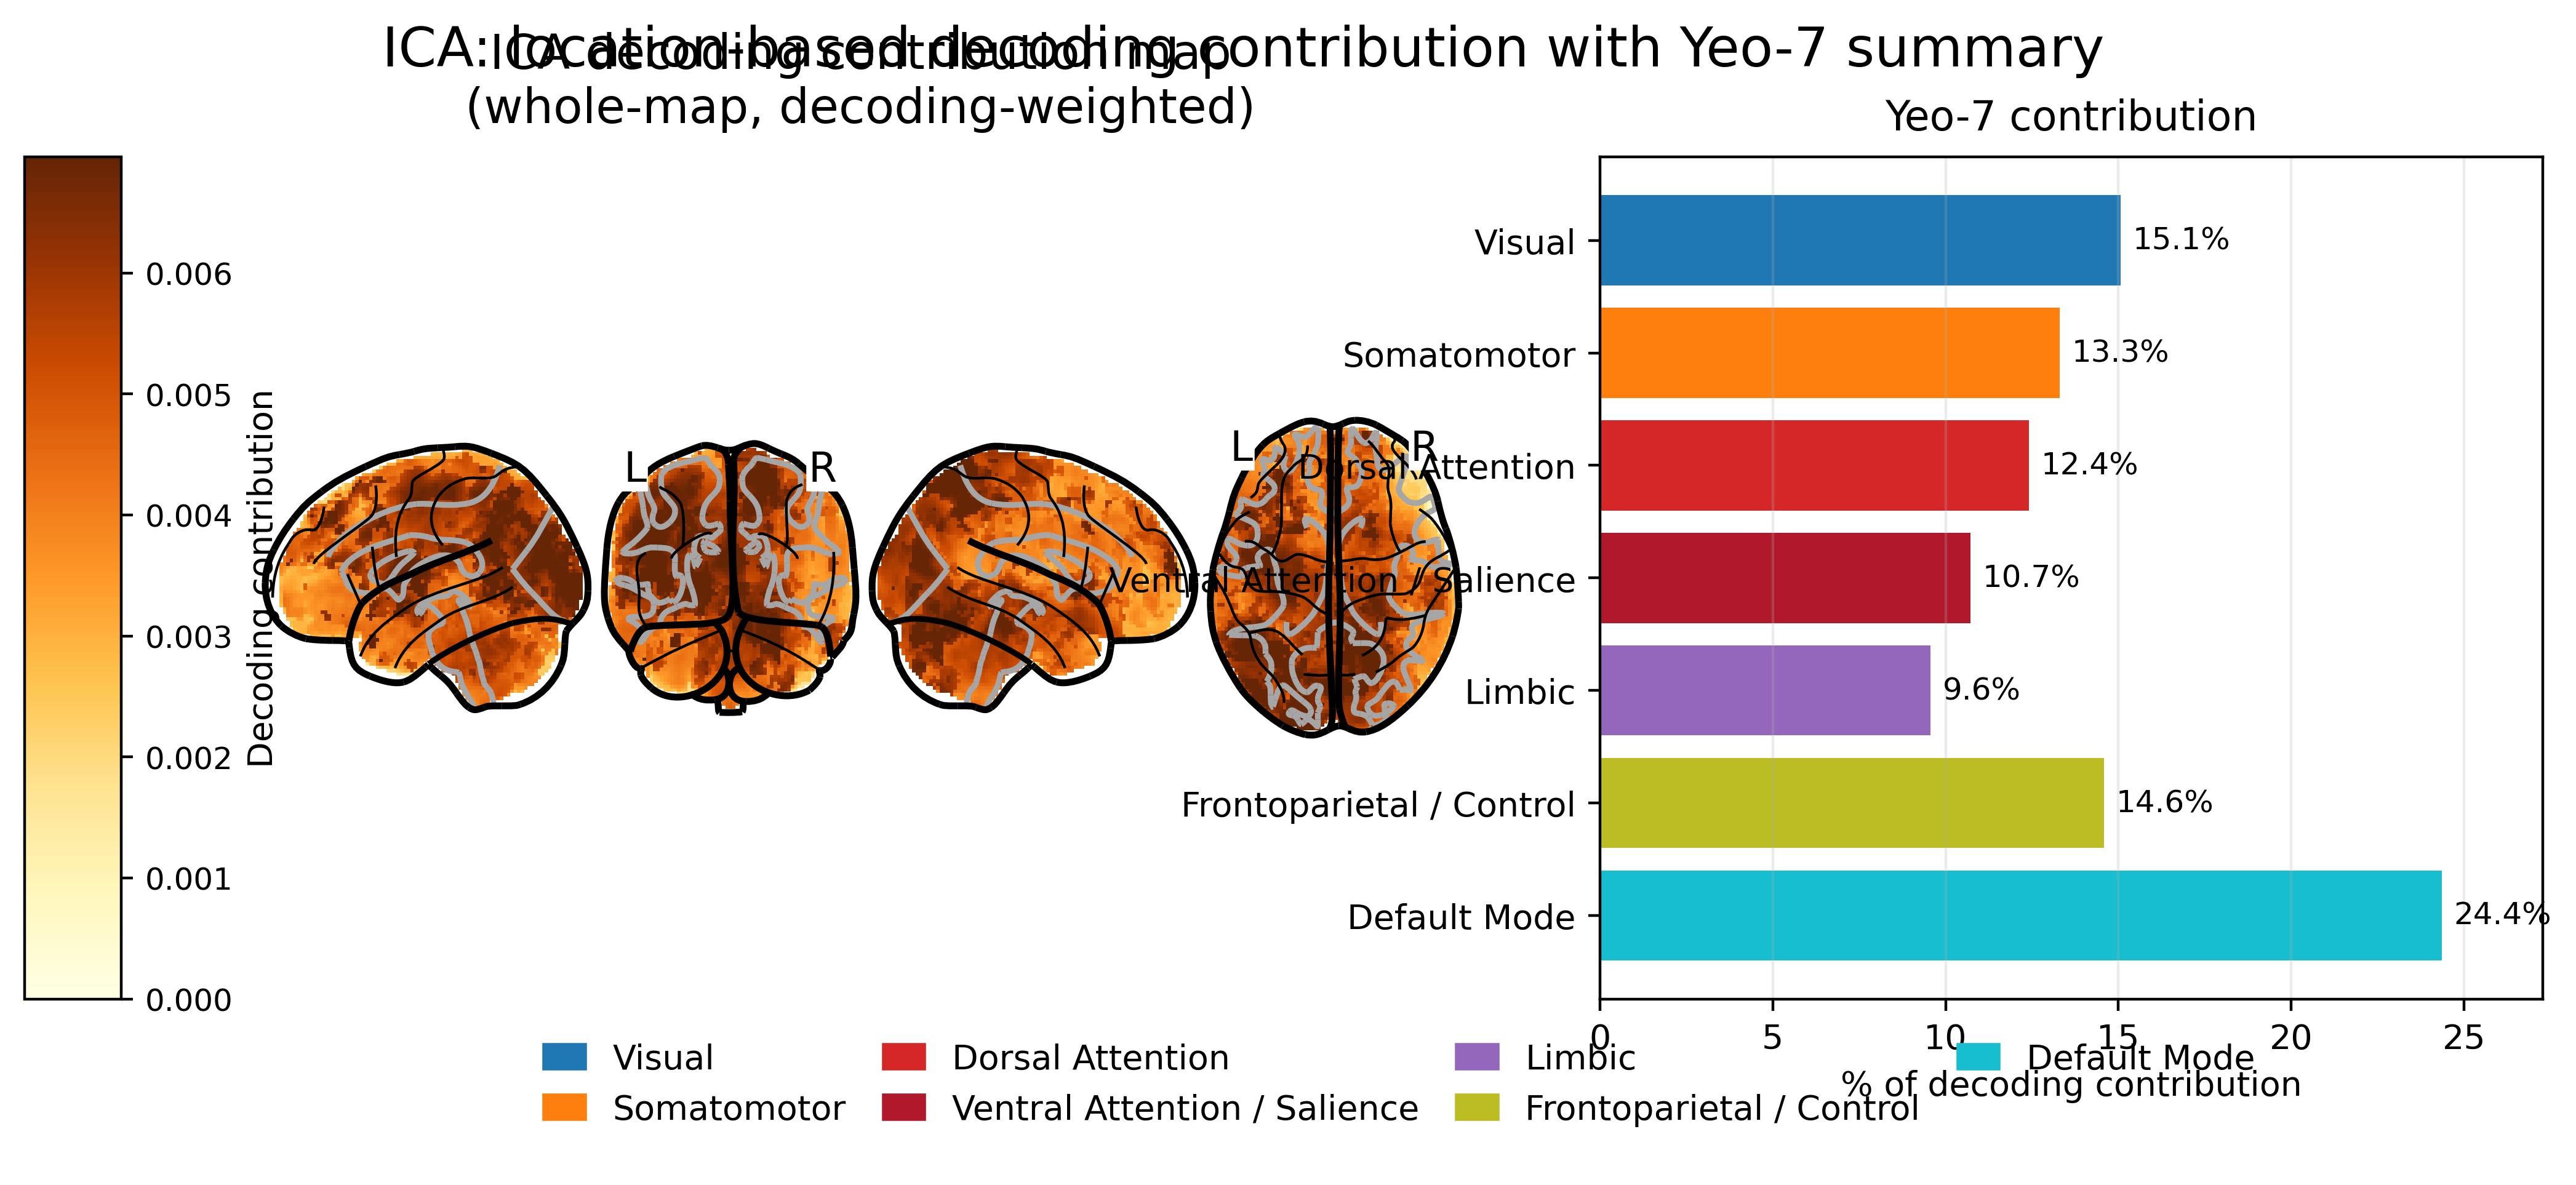

Saved final figure to: /Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA/paper_figures_partC_ica_decoding_contribution


In [6]:
# Final compact figure:
# left = one decoding-weighted brain map
# right = one Yeo-7 contribution summary

vmax = robust_vmax(contrib_img, mask_bool, pct=VMAX_PCT)

fig = plt.figure(figsize=(13.2, 5.4), dpi=DPI)
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    height_ratios=[1.0, 0.18],
    width_ratios=[0.08, 1.0, 0.78],
    wspace=0.18,
    hspace=0.02,
)

# colorbar axis
ax_cbar = fig.add_subplot(gs[0, 0])

# brain map axis
ax_brain = fig.add_subplot(gs[0, 1])
plotting.plot_glass_brain(
    contrib_img,
    display_mode=GLASS_DISPLAY_MODE,
    colorbar=False,
    cmap=CMAP,
    alpha=1.0,
    axes=ax_brain,
    plot_abs=False,
    threshold=0.0,
    vmax=vmax,
)
ax_brain.set_title(
    "ICA decoding contribution map\n(whole-map, decoding-weighted)",
    fontsize=14,
    pad=10,
)

# manual shared colorbar
norm = mpl.colors.Normalize(vmin=0.0, vmax=vmax)
cb = mpl.colorbar.ColorbarBase(ax_cbar, cmap=plt.get_cmap(CMAP), norm=norm, orientation="vertical")
cb.set_label("Decoding contribution", fontsize=10)
cb.ax.tick_params(labelsize=9)

# network summary
ax_net = fig.add_subplot(gs[0, 2])
add_network_summary(ax_net, network_df, YEO7_COLORS, plot_type=NETWORK_PLOT)

# legend row
ax_leg = fig.add_subplot(gs[1, 1:])
handles = [mpatches.Patch(color=YEO7_COLORS[i], label=YEO7_NAMES[i]) for i in range(1, 8)]
add_legend_row(ax_leg, handles, ncol=4, fontsize=10)

fig.suptitle(
    "ICA: location-based decoding contribution with Yeo-7 summary",
    fontsize=16,
    y=0.98,
)
plt.show()

fig.savefig(OUTDIR / "ica_decoding_contribution_with_yeo7.png", bbox_inches="tight", dpi=DPI)
fig.savefig(OUTDIR / "ica_decoding_contribution_with_yeo7.pdf", bbox_inches="tight")
print("Saved final figure to:", OUTDIR)


## Notes on interpretation

- This figure uses the **whole ICA component maps**, not only the top 20%.
- The voxelwise map is built as a weighted sum of component maps:

\[
D(v) = \sum_k I_k \cdot |C_k(v)|
\]

where:
- \(C_k(v)\) is the spatial weight of component \(k\) at voxel \(v\),
- \(I_k\) is the **mean decoding importance** of that component across repeated CV folds.

- Static feature coefficients are assigned fully to their component.
- Connectivity edge coefficients are split **half to each endpoint component**.
- The Yeo-7 summary is based on the **sum of contribution values inside each network**, then normalized to 100%.

So the bar chart answers:

> **What percentage of total decoding contribution falls in each canonical network?**

This is different from the older thresholded overlap plots, which mainly described where strong component voxels were located.
